In [100]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import numpy as np
import os

In [11]:
df = pd.read_csv("flow_past_cylinder/Re_43.5.csv", index_col=0)
df

,x,y,u (m/s),v (m/s),p (Pa)
0,0.014384,0.125569,0.553761,-0.016371,0.193056
1,0.000000,0.134757,0.575891,0.000000,0.198303
2,0.000000,0.117010,0.532291,0.000000,0.187153
3,0.014195,0.143272,0.591975,-0.014811,0.204417
4,0.000000,0.152352,0.609463,0.000000,0.209090
...,...,...,...,...,...
3627,2.139138,0.377955,0.208603,-0.000784,0.002350
3628,2.150110,0.361678,0.299037,-0.001534,0.001740
3629,2.167537,0.351327,0.350302,-0.001618,0.000814
3630,2.154789,0.379208,0.200404,-0.001843,0.001660


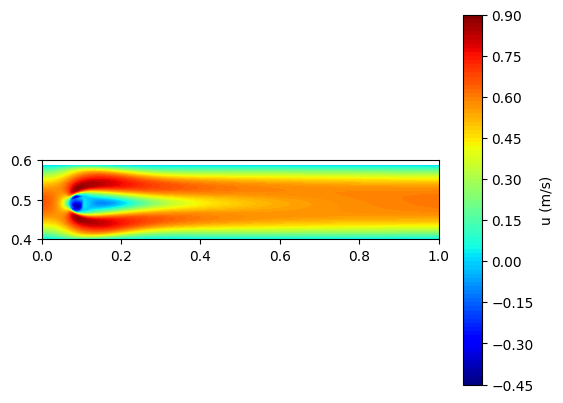

In [ ]:
x = df["x"].values
y = df["y"].values
u = df["u (m/s)"].values
p = df["p (Pa)"].values

# Scale factor so that x spans [0, 1]
scale = x.max() - x.min()

x_scaled = (x - x.min()) / scale
y_scaled = (y - y.min()) / scale   # Same scale factor preserves aspect ratio

# Create grid
xi = np.linspace(0, 1, 300)
yi = np.linspace(0.4, 0.6, 300)

X, Y = np.meshgrid(xi, yi)

# Interpolate
U = griddata((x_scaled, y_scaled+0.4), u, (X, Y), method="cubic")

# Plot
# plt.figure(figsize=(8, 4))
plt.contourf(X, Y, U, levels=100, cmap="jet")
plt.colorbar(label="u (m/s)")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.gca().set_aspect("equal")
plt.show()

In [55]:
df.head()

,x,y,u (m/s),v (m/s),p (Pa)
0,0.014384,0.125569,0.553761,-0.016371,0.193056
1,0.000000,0.134757,0.575891,0.000000,0.198303
2,0.000000,0.117010,0.532291,0.000000,0.187153
3,0.014195,0.143272,0.591975,-0.014811,0.204417
4,0.000000,0.152352,0.609463,0.000000,0.209090


In [ ]:
files = os.listdir("flow_past_cylinder")
for file in files:
    if file.endswith(".csv"):
        re = print(file.split("Re_")[-1].split(".csv")[0])

9
26.5
8
45
19.5
44
9.5
24.5
20.5
40
41
41.5
39.5
43.5
43
42
22.5
44.5
25
31
19
18
30
25.5
24
8.5
18.5
27.5
32
26
27
33
42.5
37
23
22
36
23.5
21.5
20
34
38.5
35
21
40.5
34.5
10
38
10.5
39
11
2.5
12.5
13
36.5
12
32.5
16
17
6.5
16.5
14.5
29.5
29
15
4.5
14
28
30.5
13.5
3.5
37.5
1
3
35.5
1.5
11.5
2
6
5.5
28.5
15.5
31.5
7
5
33.5
17.5
7.5
4


In [114]:
files = os.listdir("flow_past_cylinder")
for file in files:
    if file.endswith(".csv"):
        re = file.split("Re_")[-1].split(".csv")[0]

        df = pd.read_csv(f"flow_past_cylinder/Re_{re}.csv", index_col=0)

        x = df["x"].values
        y = df["y"].values
        u = df["u (m/s)"].values
        v = df["v (m/s)"].values
        p = df["p (Pa)"].values

        # Scale factor so that x spans [0, 1]
        scale = x.max() - x.min()

        x_scaled = (x - x.min()) / scale
        y_scaled = (y - y.min()) / scale  

        xi = np.linspace(0, 1, 300)
        yi = np.linspace(0, 1, 300)

        X, Y = np.meshgrid(xi, yi)
        U = griddata((x_scaled, y_scaled+0.4), u, (X, Y), method="cubic")
        V = griddata((x_scaled, y_scaled+0.4), v, (X, Y), method="cubic")
        P = griddata((x_scaled, y_scaled+0.4), p, (X, Y), method="cubic")



        new_df = pd.DataFrame({
                                "x": X.flatten(),
                                "y": Y.flatten(),
                                "u (m/s)": U.flatten(),
                                "v (m/s)": V.flatten(),
                                "p (Pa)" : P.flatten(),
                            })

        # plt.contourf(X, Y, U, levels=100, cmap="jet")
        # plt.colorbar(label="u (m/s)")

        new_df.to_csv(f"flow_past_cylinder_domain/Re_{re}.csv")

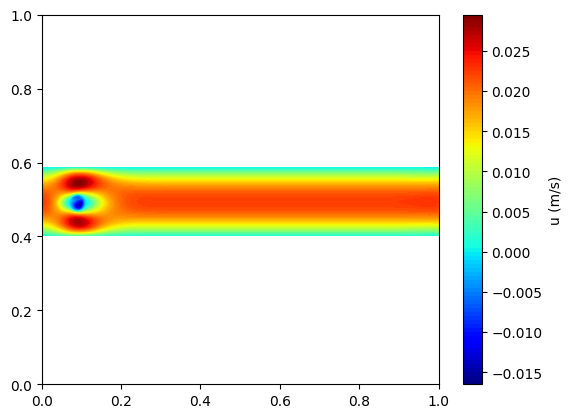

In [ ]:
df = pd.read_csv("flow_past_cylinder/Re_1.5.csv", index_col=0)
df = pd.read_csv("flow_past_cylinder/Re_1.5.csv", index_col=0)

x = df["x"].values
y = df["y"].values
u = df["u (m/s)"].values
v = df["v (m/s)"].values
p = df["p (Pa)"].values

# Scale factor so that x spans [0, 1]
scale = x.max() - x.min()

x_scaled = (x - x.min()) / scale
y_scaled = (y - y.min()) / scale  

xi = np.linspace(0, 1, 300)
yi = np.linspace(0, 1, 300)

X, Y = np.meshgrid(xi, yi)
U = griddata((x_scaled, y_scaled+0.4), u, (X, Y), method="cubic")
V = griddata((x_scaled, y_scaled+0.4), v, (X, Y), method="cubic")
P = griddata((x_scaled, y_scaled+0.4), p, (X, Y), method="cubic")



new_df = pd.DataFrame({
                        "x": X.flatten(),
                        "y": Y.flatten(),
                        "u (m/s)": U.flatten(),
                        "v (m/s)": V.flatten(),
                        "p (Pa)" : P.flatten(),
                    })

plt.contourf(X, Y, U, levels=100, cmap="jet")
plt.colorbar(label="u (m/s)")

In [ ]:
new_df.to_csv("flow_past_cylinder_domain/")

16800

In [107]:
new_df["x"].values

array([0.        , 0.00334448, 0.00668896, ..., 0.99331104, 0.99665552,
       1.        ])

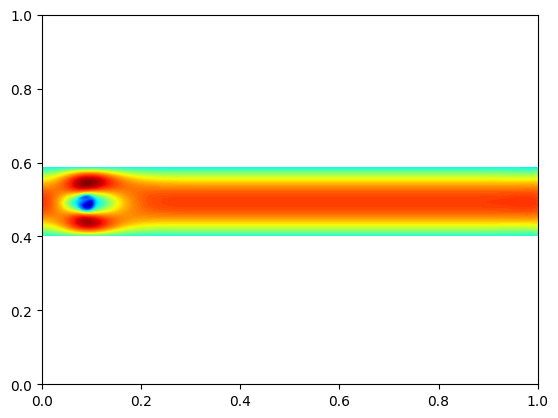

In [ ]:
# Create grid

newer_df = pd.read_csv("flow_past_cylinder_domain/Re_1.5.csv", index_col=0)

xi = np.linspace(0, 1, 300)
yi = np.linspace(0, 1, 300)

x = newer_df["x"].values
y = newer_df["y"].values
u = newer_df["u (m/s)"].values


X, Y = np.meshgrid(xi, yi)

mask = ~np.isnan(u)
# Interpolate
U = griddata((x[mask], y[mask]), u[mask], (X, Y), method="cubic")

# Plot
# plt.figure(figsize=(8, 4))
plt.contourf(X, Y, U, levels=100, cmap="jet")

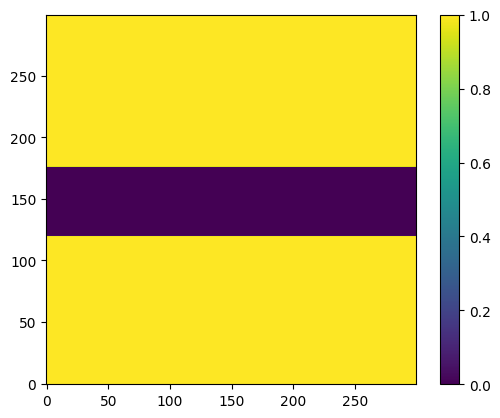

In [91]:
plt.imshow(np.isnan(P), origin="lower")
plt.colorbar()